# Example Workflow

This notebook provides an example of using the ``rowland_geometry`` module in a typical workflow. In this worked example, the an asymmetric Rowland geometry is investigated for a Pu M-edge HERFD measurement and a the module is used to generate a rudimentary scan definition for the measurement with the detector tracking behind the Rowland circle at the sagittal focus.

#### 0. Background

A Pu M-edge HERFD measurement requires the spectrometer to analyze the intensity of a Pu M-shell emission line while the upstream monochromator energy is scanned over the Pu M-edge. The emission line energy is 3728 eV, which requires a Si(220) reflection for photon analysis at a Bragg angle of 59.99 deg. 

Due to Johann error at this unfavorable Bragg angle far from backscatter, the energy resolution of the spherically bent crystal analyzer is  significantly degraded. Recent work has demonstrated Johann error can be suppressed and energy resolution recovered by employing asymmetric reflections of the spherically bent optic resulting in an asymmetric Rowland geometry. In this case, the plane family used for photon analysis differs from the nominally surface co-incident plane family (i.e., the cut) of the optic. 

A package, ``hklhop``, has been developed for the surveying of optic cuts and available asymmetric reflections at a given energy ([text](https://github.com/Seidler-Lab/hklhop)). A survey has already been conducted at the Pu M-shell fluorescence line at 3728 eV for a suitable combination of cut and asymmetric reflection that can suppress Johann error and provide improved energy resolution. Output from this survey is shown below, where G0 denotes the cut of the optic and Ghkl the asymmetric reflection for photon analysis: 

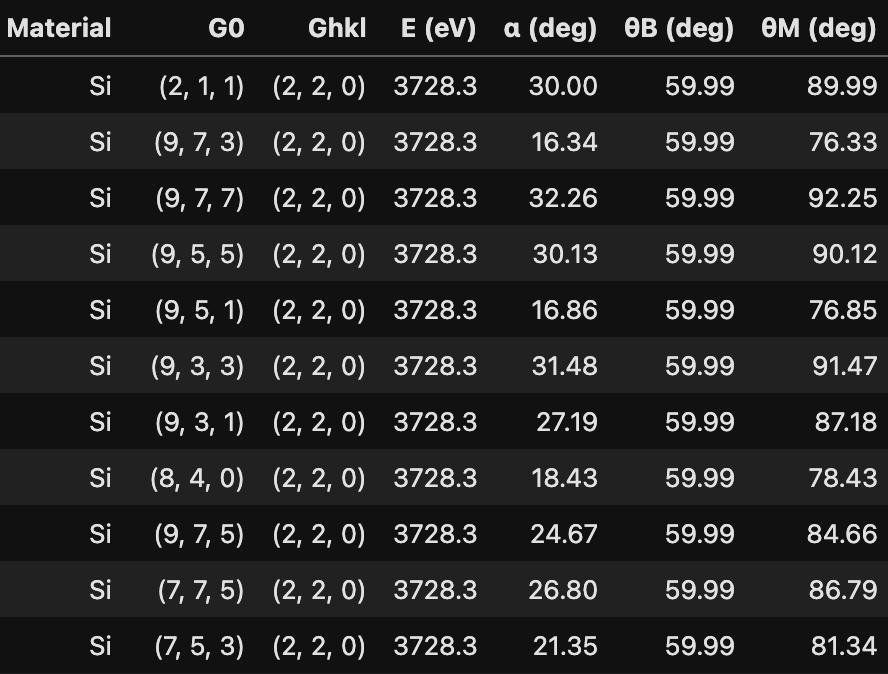

In this case, with the emission line in the tender X-ray regime, there is only a single suitable silicon reflection for photon analysis of this emission line, (2,2,0), at the same Bragg angle of 59.99 deg. Thus, the best analyzer for asymmetric operation will have an asymmetry angle plus Bragg angle equal to 90 deg. At this condition Johann error is completely suppressed. Severral candidates are suitable, but for simplicity, the best spherically bent crystal analyzer for this measurement is Si(2,1,1) using the (2,2,0) reflection for photon analysis. The angle between the cut and reflection is 30 deg, satisfying the condition that suppressed Johann error.

So -- using a Si(211) analyzer and the asymmetric (220) reflection to analyze Pu fluorescence at 3728 eV, what is the geometry of the spectrometer, position of the detector, and range of motion necessary to make this measurement asymmetrically? 


#### 1. Initializing the Spectrometer

In [4]:
from rowland_geometry import Analyzer, RowlandSpectrometer, ReferenceFrame

# Instantiating the analyzer
sbca = Analyzer(
    material="Si",                          
    reflection=[2, 2, 0],
    cut=[2,1,1],       
    bending_radius=1000,
    optic_diameter=100
    )

# Defining the reference frame
tbl_frame = ReferenceFrame(
    origin="source",              # the source is always fixed at the origin
    axis_element="analyzer",      # the analyzer must remain on an axis
    axis="x",                     # the analyzer is always in the horizontal plane
    )

# Instantiating the spectrometer with a reference frame
xas_spec = RowlandSpectrometer(
    analyzer=sbca,
    energy=3728,
    frame=tbl_frame   
    )

#### 2. Plotting the Rowland Geometry

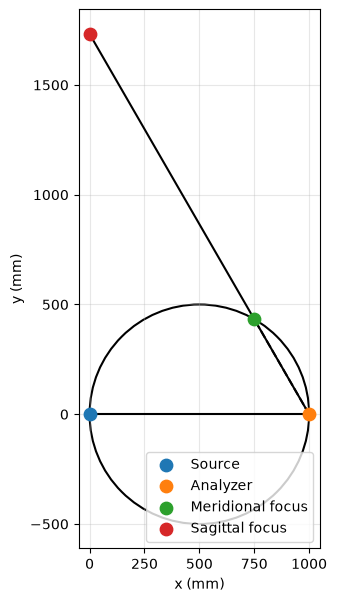

In [5]:
# Plot geometry
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

coords = xas_spec.coords_reference_frame()
fig, ax = plt.subplots(figsize=(7, 7))

center = coords["center"]
ax.add_patch(
    Circle(
        center[:2],
        xas_spec.diameter / 2,
        fill=False,
        color="k",
        lw=1.5,
    )
)

# Source-analyzer and analyzer-focus paths
for start, end, ls in [
    ("source", "analyzer", "-"),
    ("analyzer", "sagittal", "-"),
    ("analyzer", "meridional", "--"),
]:
    ax.plot(
        *zip(coords[start][:2], coords[end][:2]),
        color="k",
        ls=ls,
        lw=1.5,
    )

# Optical elements and foci
for name, label in [
    ("source", "Source"),
    ("analyzer", "Analyzer"),
    ("meridional", "Meridional focus"),
    ("sagittal", "Sagittal focus"),
]:
    ax.scatter(*coords[name][:2], s=80, label=label, zorder=10)

ax.set(
    xlabel="x (mm)",
    ylabel="y (mm)",
    aspect="equal",
)

ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.show()

#### 3. Inspecting the coordinates and tilt angle